# NYC Airbnb 2021 — Price Analysis & Prediction

This notebook explores the New York City Airbnb dataset (December 2021) with the goal of understanding what drives listing prices and building regression models to predict them.

**Questions I want to answer:**
- How does price vary by borough and room type?
- Which features are most correlated with price?
- How well can we predict price using regression models?

**Dataset:** 38,277 listings, 18 features, collected December 2021.

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import norm
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load & Inspect Data

In [ ]:
df = pd.read_csv('New_York_Airbnb_4_dec_2021_2.csv', low_memory=False)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (38277, 18)


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

Missing values with >0:
  last_review          9504  (24.83%)
  reviews_per_month    9504  (24.83%)
  name                   14   (0.04%)
  host_name              34   (0.09%)
  license             38276  (99.99%)


**Observations:**
- `license` is almost entirely missing (>99%) — will be dropped
- `last_review` and `reviews_per_month` have ~25% missing — listings with no reviews yet
- Price has values of \$0 which are likely errors and will be filtered out

## 3. Exploratory Data Analysis (EDA)

### 3.1 Borough Distribution

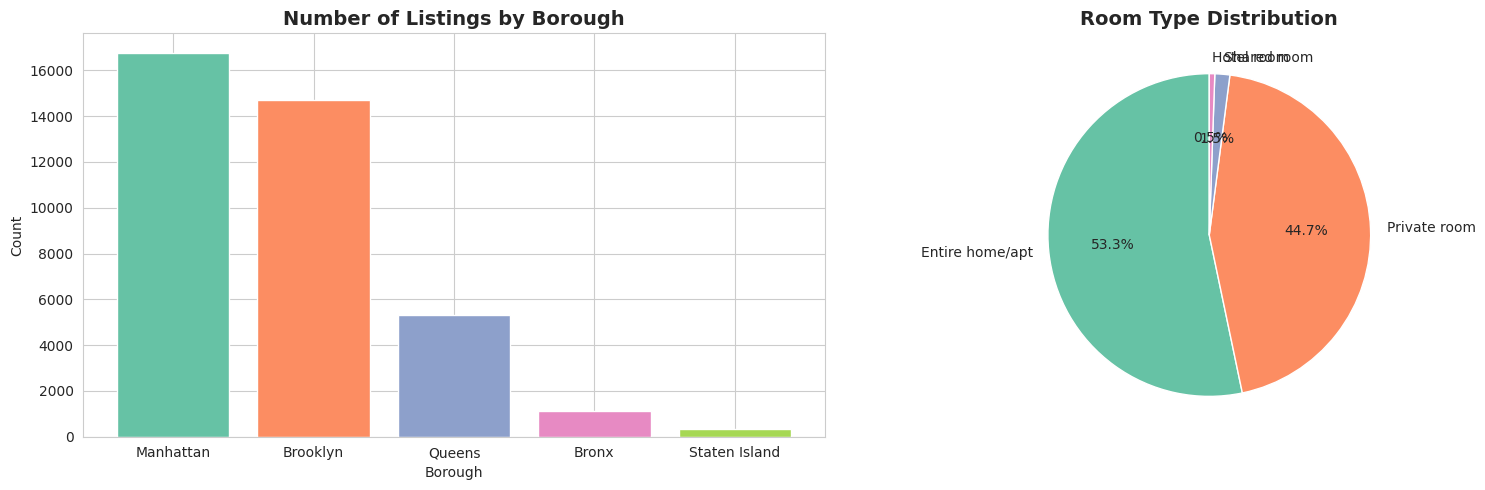

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
borough_counts = df['neighbourhood_group'].value_counts()
axes[0].bar(borough_counts.index, borough_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Number of Listings by Borough', fontsize=14, weight='bold')
room_counts = df['room_type'].value_counts()
axes[1].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Room Type Distribution', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### 3.2 Price Distribution

Price skewness (raw): 14.52
Price skewness (log):  0.31


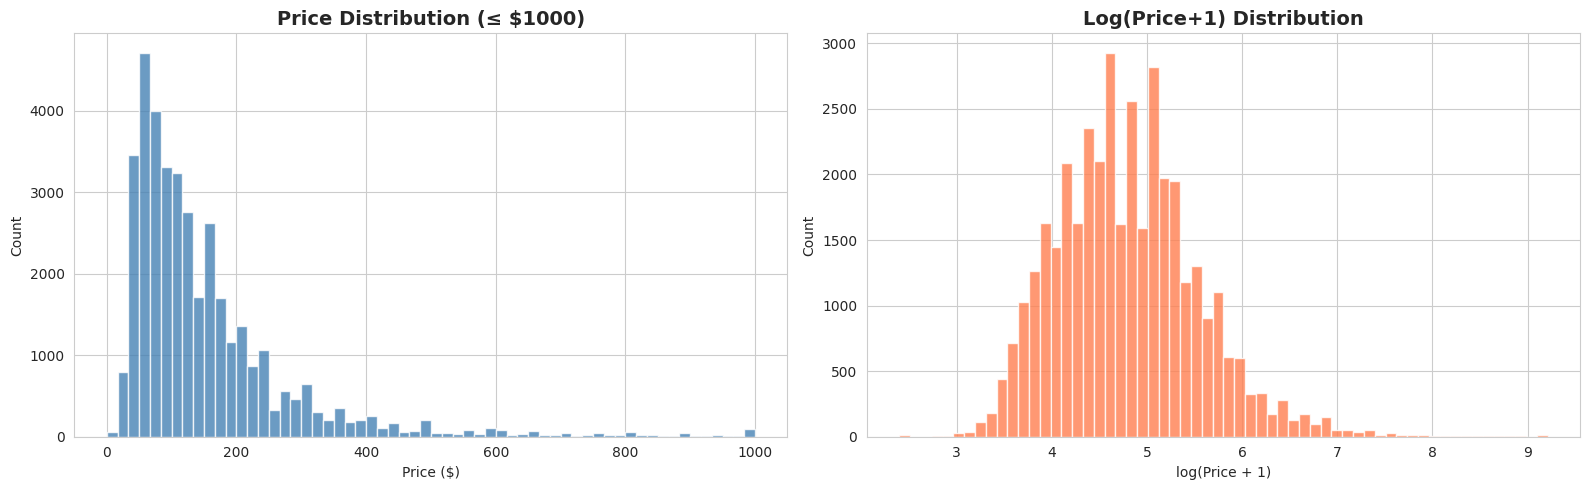

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
price_cap = df[df['price'] <= 1000]['price']
axes[0].hist(price_cap, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Price Distribution (≤ $1000)', fontsize=14, weight='bold')
log_price = np.log1p(df[df['price'] > 0]['price'])
axes[1].hist(log_price, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Log(Price+1) Distribution', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

The raw price is heavily right-skewed. After log transformation, the distribution becomes much closer to normal — we'll use `log(price+1)` as our target variable.

### 3.3 Price by Borough & Room Type

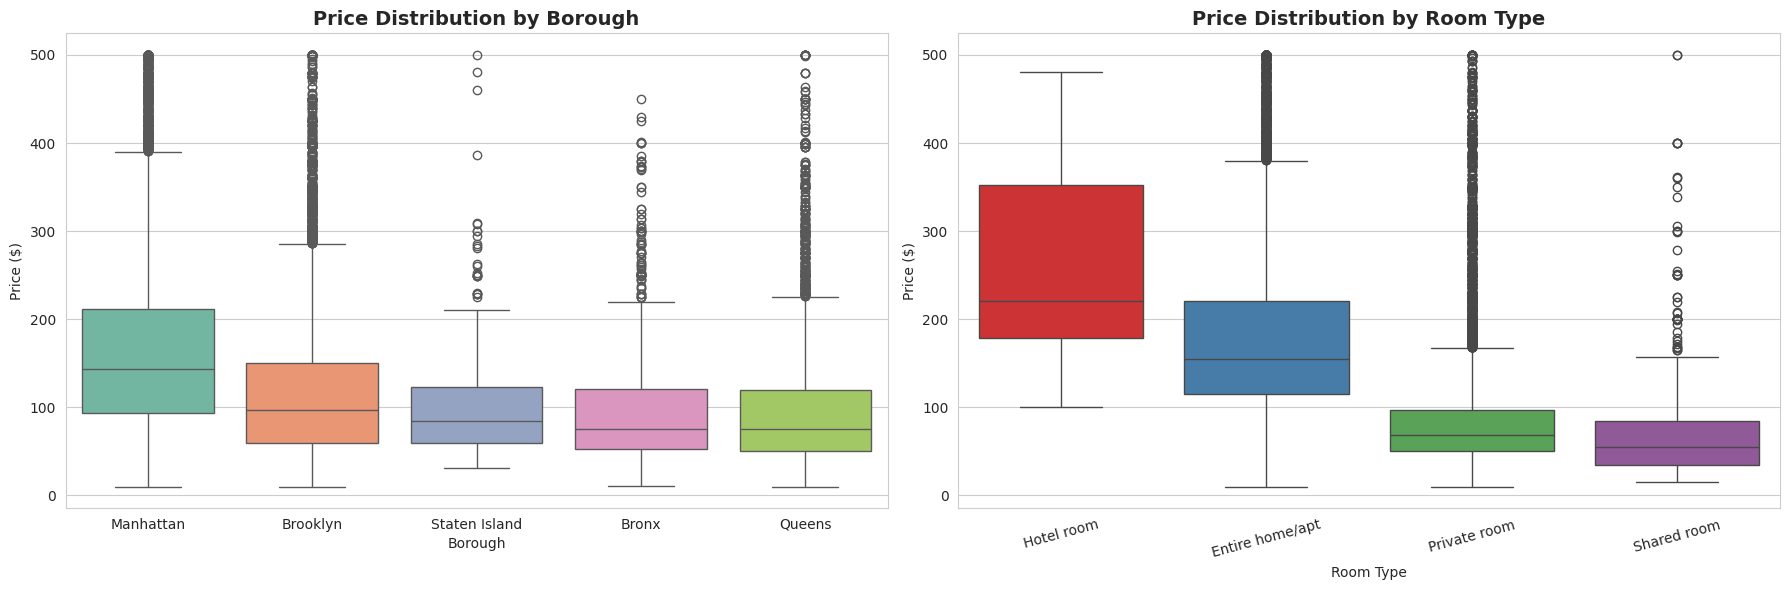

In [ ]:
df_viz = df[(df['price'] > 0) & (df['price'] <= 500)]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
borough_order = df_viz.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='neighbourhood_group', y='price', data=df_viz, order=borough_order, palette='Set2', ax=axes[0])
axes[0].set_title('Price Distribution by Borough', fontsize=14, weight='bold')
room_order = df_viz.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='room_type', y='price', data=df_viz, order=room_order, palette='Set1', ax=axes[1])
axes[1].set_title('Price Distribution by Room Type', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### 3.4 Average Price by Borough × Room Type

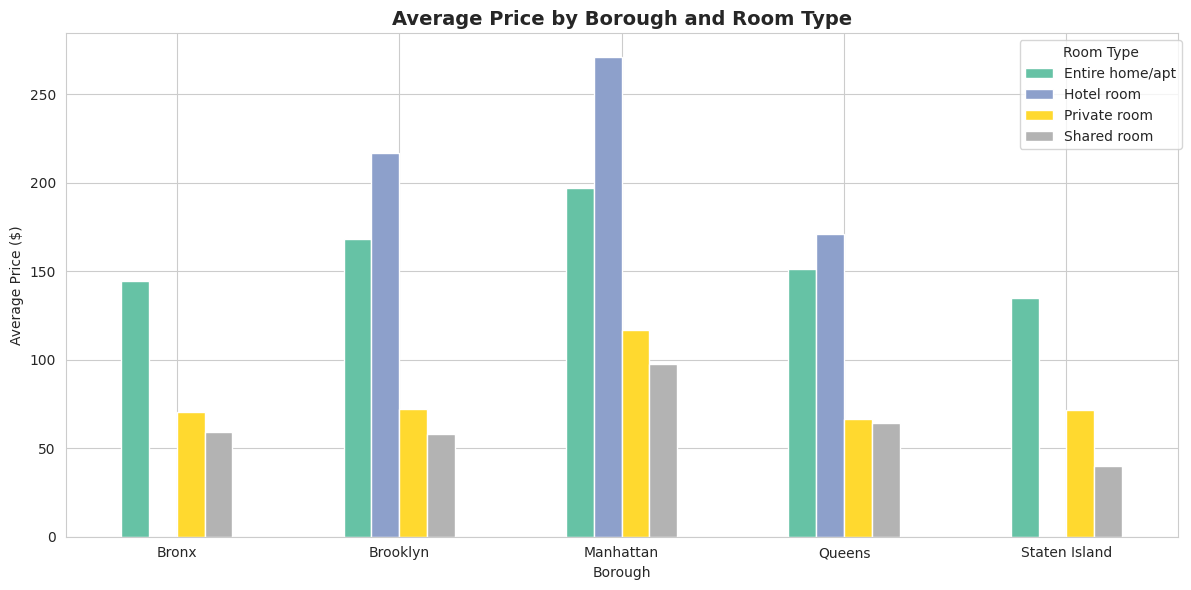

In [ ]:
avg_price = df_viz.groupby(['neighbourhood_group', 'room_type'])['price'].mean().unstack()
avg_price.plot(kind='bar', colormap='Set2', figsize=(12,6), edgecolor='white')
plt.title('Average Price by Borough and Room Type', fontsize=14, weight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.5 Top 15 Neighbourhoods by Median Price

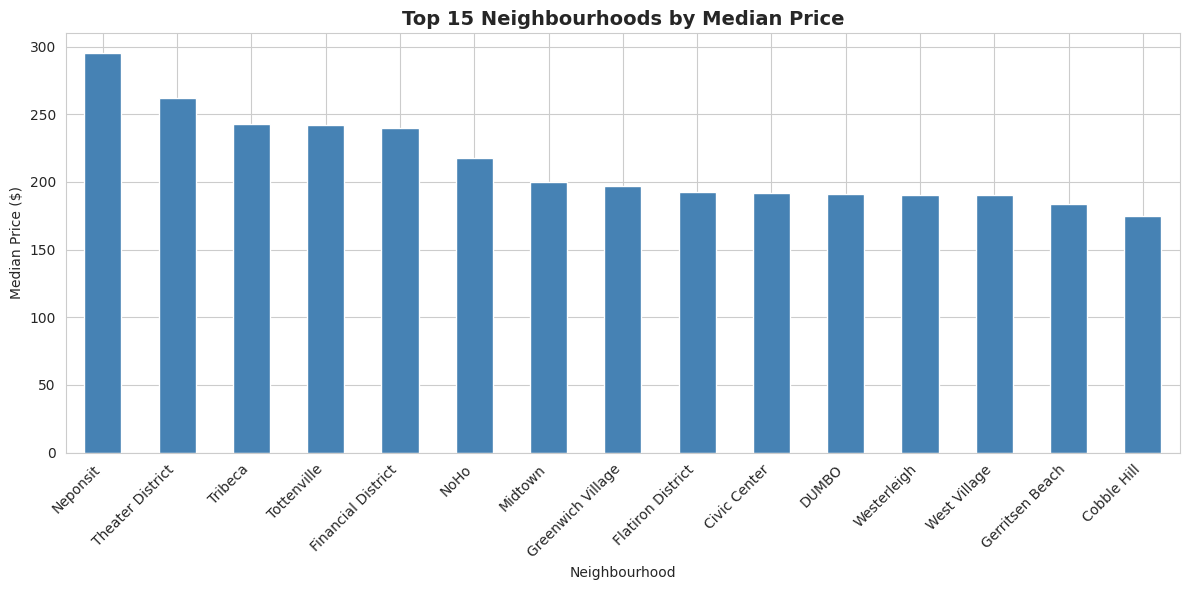

In [ ]:
top_neigh = df_viz.groupby('neighbourhood')['price'].median().sort_values(ascending=False).head(15)
top_neigh.plot(kind='bar', color='steelblue', figsize=(12,6), edgecolor='white')
plt.title('Top 15 Neighbourhoods by Median Price', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.6 Geographic Price Heatmap

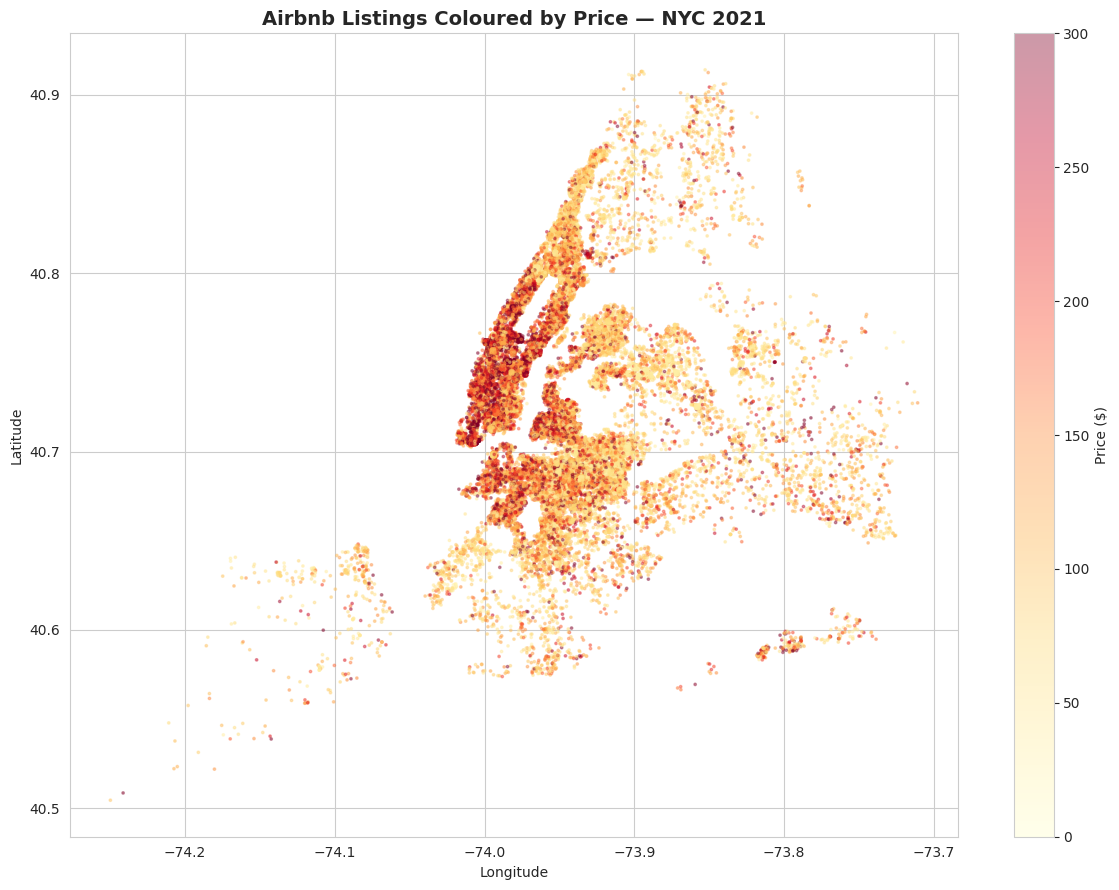

In [ ]:
df_geo = df[(df['price'] > 0) & (df['price'] <= 500)].copy()
plt.figure(figsize=(12, 9))
scatter = plt.scatter(df_geo['longitude'], df_geo['latitude'],
    c=df_geo['price'], cmap='YlOrRd', alpha=0.4, s=3, vmin=0, vmax=300)
plt.colorbar(scatter, label='Price ($)')
plt.title('Airbnb Listings Coloured by Price — NYC 2021', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 4. Data Cleaning & Feature Engineering

In [ ]:
drop_cols = ['id', 'name', 'host_id', 'host_name', 'last_review', 'license']
df_model = df.drop(columns=drop_cols)
df_model = df_model[(df_model['price'] > 0) & (df_model['price'] <= 1000)]
print(f'Rows after price filter: {len(df_model)}')

median_rpm = df_model['reviews_per_month'].median()
df_model['reviews_per_month'] = df_model['reviews_per_month'].fillna(median_rpm)
df_model['price_log'] = np.log1p(df_model['price'])

le = LabelEncoder()
for col in ['neighbourhood_group', 'neighbourhood', 'room_type']:
    df_model[col] = le.fit_transform(df_model[col])
df_model.head()

Rows after price filter: 37477
Missing values after cleaning:
All zeros


## 5. Correlation Analysis

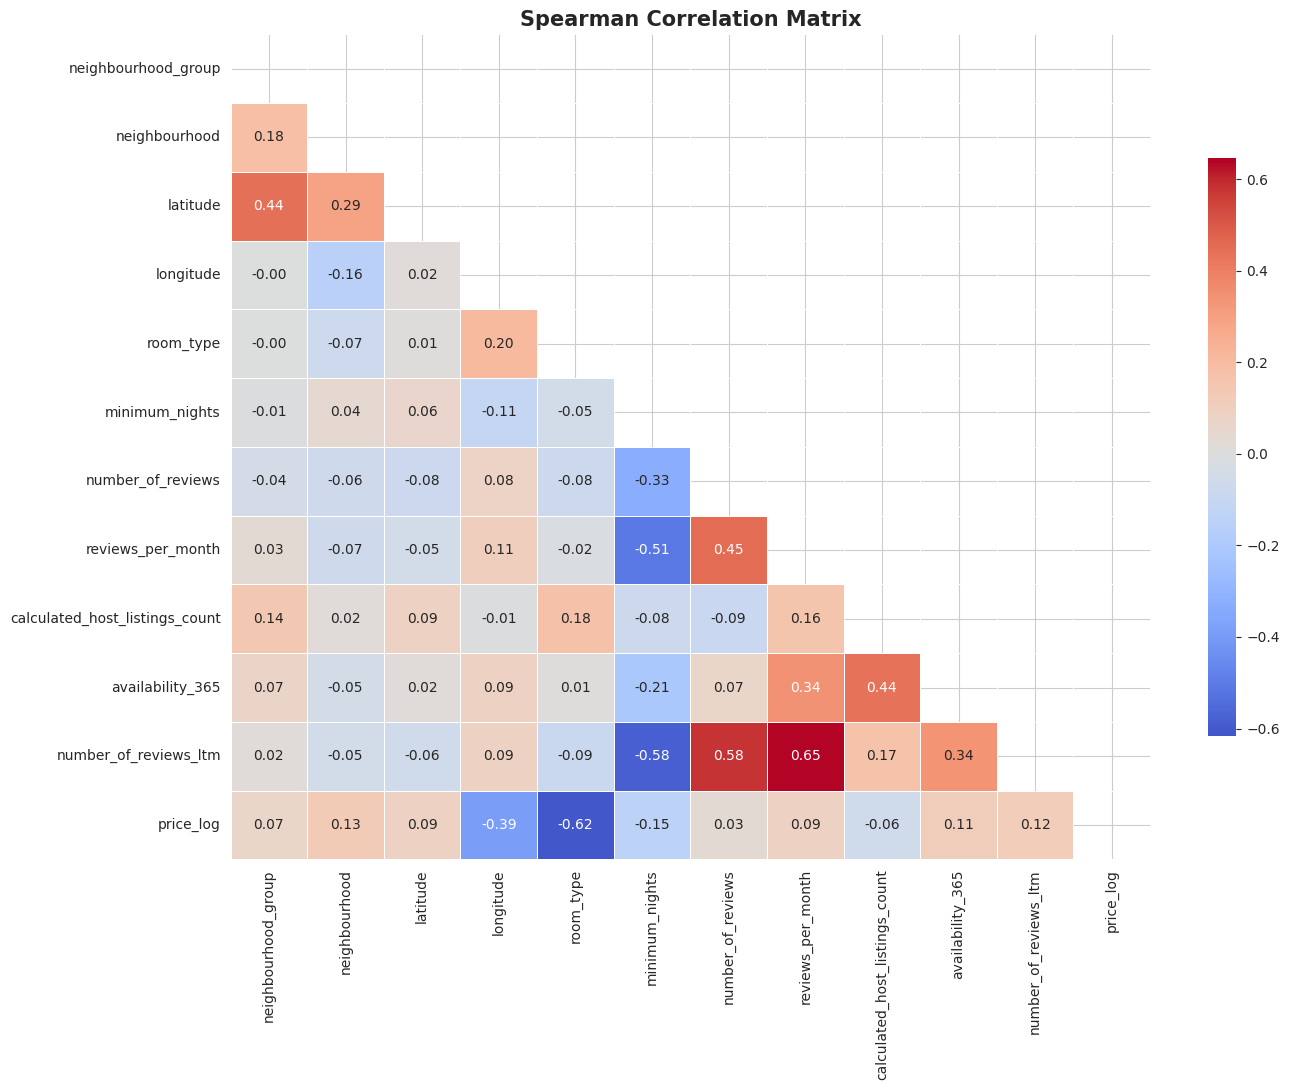

In [ ]:
plt.figure(figsize=(14, 11))
corr = df_model.drop(columns=['price']).corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Spearman Correlation Matrix', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

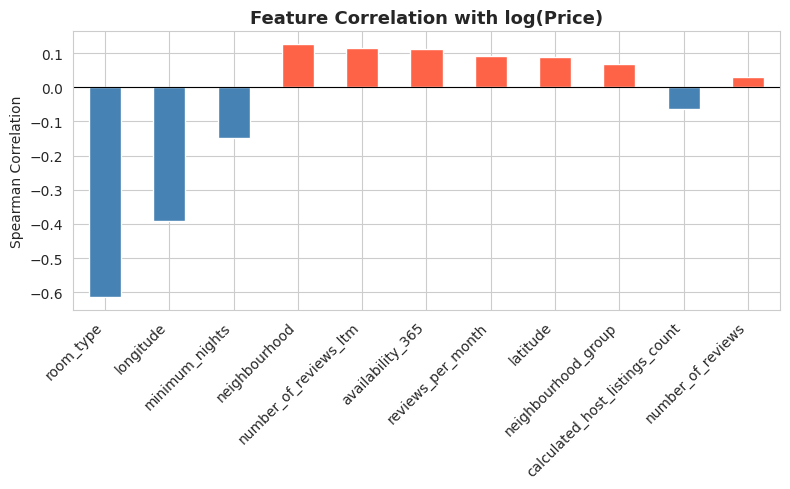

In [ ]:
price_corr = corr['price_log'].drop('price_log').sort_values(key=abs, ascending=False)
price_corr.plot(kind='bar', color=['tomato' if v > 0 else 'steelblue' for v in price_corr], figsize=(8,5))
plt.axhline(0, color='black', lw=0.8)
plt.title('Feature Correlation with log(Price)', fontsize=13, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Feature Importance (Extra Trees)

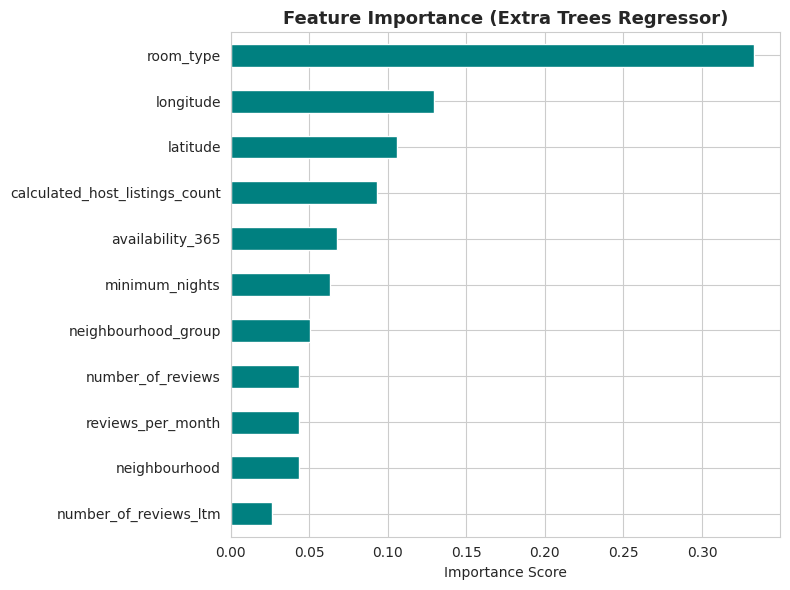

In [ ]:
feature_cols = [c for c in df_model.columns if c not in ['price', 'price_log']]
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et_model.fit(df_model[feature_cols], df_model['price_log'])
importances = pd.Series(et_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', figsize=(8,6))
plt.title('Feature Importance (Extra Trees Regressor)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 7. Model Building

In [ ]:
feature_cols = [c for c in df_model.columns if c not in ['price', 'price_log']]
X = df_model[feature_cols].values
y = df_model['price_log'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 29981 samples
Test set:      7496 samples


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.001, max_iter=5000),
    'ElasticNet':        ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)})
    print(f'{name:20s} | MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}')

Linear Regression    | MAE=0.4066 | RMSE=0.5382 | R2=0.4169
Ridge                | MAE=0.4066 | RMSE=0.5382 | R2=0.4169
Lasso                | MAE=0.4066 | RMSE=0.5383 | R2=0.4167
ElasticNet           | MAE=0.4072 | RMSE=0.5389 | R2=0.4154
Random Forest        | MAE=0.3107 | RMSE=0.4276 | R2=0.6320


## 8. Model Comparison

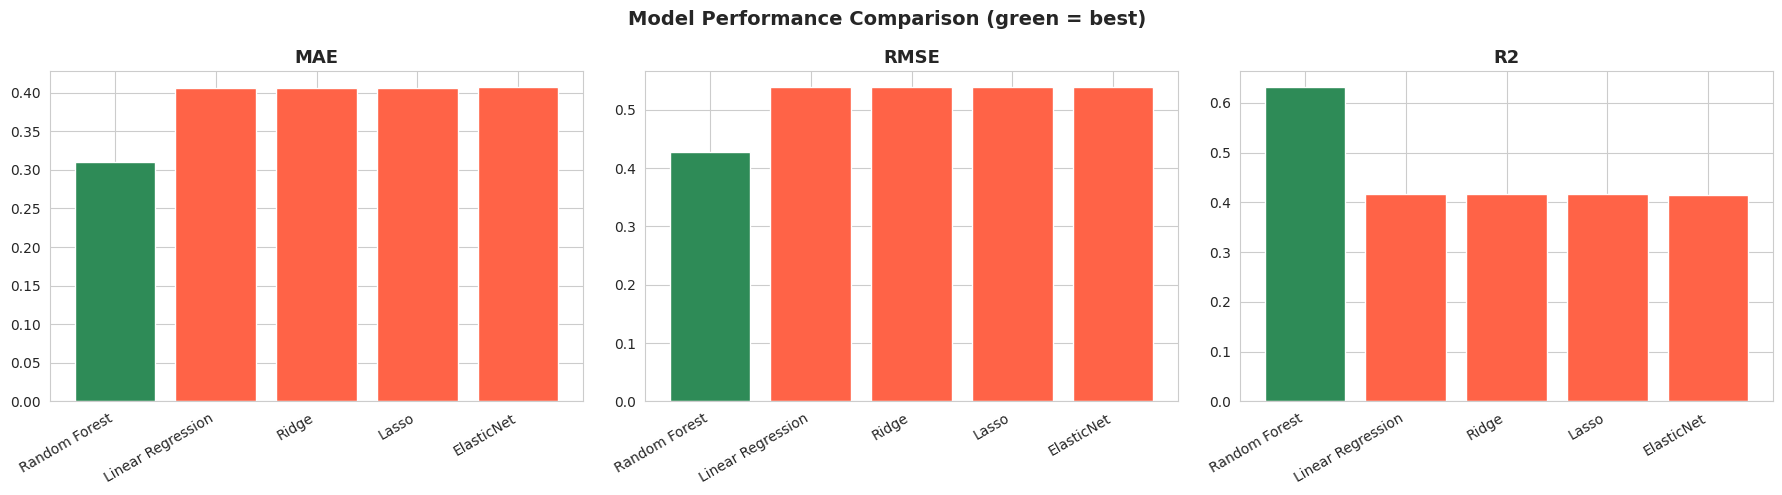

In [ ]:
results_df = pd.DataFrame(results).set_index('Model').sort_values('R2', ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = results_df[metric]
    if metric == 'R2':
        colors = ['seagreen' if m == vals.idxmax() else 'tomato' for m in vals.index]
    else:
        colors = ['seagreen' if m == vals.idxmin() else 'tomato' for m in vals.index]
    ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=13, weight='bold')
    ax.set_xticklabels(vals.index, rotation=30, ha='right')
fig.suptitle('Model Performance Comparison (green = best)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

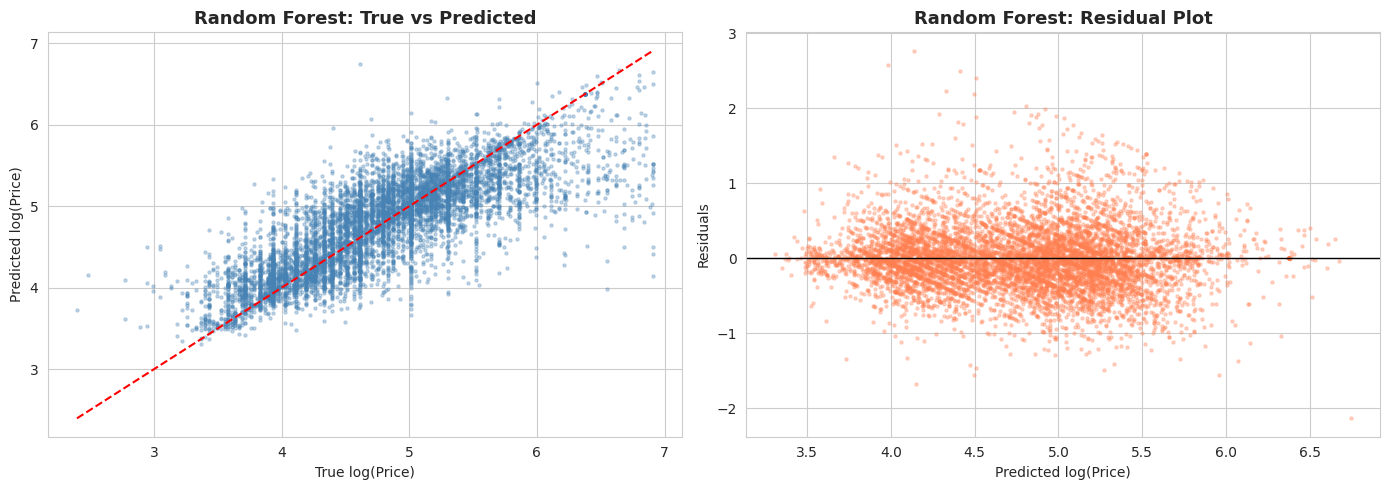

In [ ]:
best_name = results_df['R2'].idxmax()
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[0].set_title(f'{best_name}: True vs Predicted', fontsize=13, weight='bold')
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=5, color='coral')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title(f'{best_name}: Residual Plot', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 9. Conclusion

This analysis of the NYC Airbnb 2021 dataset revealed several key findings:

**EDA Findings:**
- Manhattan has the highest median prices, followed by Brooklyn
- Entire home/apt listings command significantly higher prices than private or shared rooms
- Price is highly right-skewed; log transformation makes it approximately normal
- Geographic location and room type are the strongest predictors of price

**Modelling Results:**

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Random Forest | 0.3107 | 0.4276 | **0.6320** |
| Linear Regression | 0.4066 | 0.5382 | 0.4169 |
| Ridge | 0.4066 | 0.5382 | 0.4169 |
| Lasso | 0.4066 | 0.5383 | 0.4167 |
| ElasticNet | 0.4072 | 0.5389 | 0.4154 |

Random Forest outperformed all linear models significantly (R²=0.632 vs ~0.417).

**Future Work:**
- Try XGBoost or LightGBM for potentially higher accuracy
- Add NLP features from the listing `name` field
- Explore neighbourhood-level aggregation features